# 🎵 SongNet: End-to-End Music Genre Classification on FMA (8,000 Tracks)
**Complete Training Pipeline for Stanford CS229 Paper #53 Re-implementation**

* **Paper Reference**: *SongNet: Real-Time Music Genre Classification* (Zhang, Zhang, Chen - Stanford CS229, 2018)
* **Dataset**: Free Music Archive (FMA) Small (8,000 audio tracks, 8 balanced genres, 30s each)
* **Primary Deep Learning Model**: PyTorch Convolutional-Recurrent Neural Network (**SongNet C-RNN ~65.23% Test Accuracy**)
* **Baseline Classical ML Models**: Linear SVM (~46.38%), MLP (~44.88%), Logistic Regression (~42.25%), kNN (~36.38%)
* **Saved Outputs**: `best.pt` (PyTorch C-RNN weights) and `baselines.joblib` (Scikit-Learn baseline models)


In [1]:
# ==========================================
# CELL 1: Package Installations & Global Imports
# ==========================================
!pip install -q librosa soundfile scikit-learn matplotlib seaborn pandas tqdm torch torchaudio gradio joblib

import os
import sys
import glob
import json
import zipfile
import urllib.request
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from scipy.stats import skew

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import librosa
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
import joblib

# Set Random Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🚀 Execution Device: {device}')


🚀 Execution Device: cpu


In [3]:
# ==========================================
# CELL 2: Automatic Dataset Downloader & Flexible File Discovery
# ==========================================
import os, sys, glob, zipfile, urllib.request, re
os.makedirs('./data', exist_ok=True)

print('Searching for FMA metadata and audio files...')
tracks_csv_matches = glob.glob('/kaggle/input/**/tracks.csv', recursive=True) + \
                     glob.glob('./**/*tracks.csv', recursive=True) + \
                     glob.glob('../**/*tracks.csv', recursive=True)

if len(tracks_csv_matches) > 0:
    METADATA_CSV = tracks_csv_matches[0]
    print(f'✓ Found tracks.csv metadata at: {METADATA_CSV}')
else:
    print('Downloading fma_metadata.zip (342 MB)...')
    METADATA_ZIP = './data/fma_metadata.zip'
    if not os.path.exists(METADATA_ZIP):
        urllib.request.urlretrieve('https://os.unil.cloud.switch.ch/fma/fma_metadata.zip', METADATA_ZIP)
    print('Unzipping metadata...')
    with zipfile.ZipFile(METADATA_ZIP, 'r') as z:
        z.extractall('./data')
    METADATA_CSV = glob.glob('./**/*tracks.csv', recursive=True)[0]

mp3_matches = glob.glob('/kaggle/input/**/*.mp3', recursive=True) + \
              glob.glob('./**/*.mp3', recursive=True)

if len(mp3_matches) < 100:
    print('Downloading fma_small.zip (7.2 GB audio dataset)...')
    AUDIO_ZIP = './data/fma_small.zip'
    if not os.path.exists(AUDIO_ZIP):
        urllib.request.urlretrieve('https://os.unil.cloud.switch.ch/fma/fma_small.zip', AUDIO_ZIP)
    print('Unzipping fma_small.zip...')
    with zipfile.ZipFile(AUDIO_ZIP, 'r') as z:
        z.extractall('./data')
    mp3_matches = glob.glob('./**/*.mp3', recursive=True)

print(f'✓ Total MP3 audio files discovered: {len(mp3_matches)}')


Searching for FMA metadata and audio files...
✓ Found tracks.csv metadata at: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv
✓ Total MP3 audio files discovered: 33000


In [4]:
# ==========================================
# CELL 3: Load Metadata & Filter 8,000 FMA Small Tracks
# ==========================================
SAMPLE_RATE = 22050
DURATION = 30  # seconds
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

GENRES = ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for i, g in enumerate(GENRES)}

# Read multi-index CSV
tracks_df = pd.read_csv(METADATA_CSV, index_col=0, header=[0, 1])
small_df = tracks_df[tracks_df[('set', 'subset')] == 'small']

print(f'✓ Loaded metadata for {len(small_df)} FMA Small tracks across 8 genres.')
print(small_df[('track', 'genre_top')].value_counts())


✓ Loaded metadata for 8000 FMA Small tracks across 8 genres.
(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


In [5]:
# ==========================================
# CELL 4: Robust Spectrogram & Feature Extraction Pipeline
# ==========================================
def audio_to_mel(y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    log_mel = np.log(1.0 + 10000.0 * mel_spec)
    return log_mel.astype(np.float32)

def extract_features_from_mel(mel):
    mean_val = np.mean(mel, axis=1)
    std_val = np.std(mel, axis=1)
    skew_val = skew(mel, axis=1)
    max_val = np.max(mel, axis=1)
    min_val = np.min(mel, axis=1)
    return np.hstack([mean_val, std_val, skew_val, max_val, min_val])

print(f'Indexing {len(mp3_matches)} discovered audio files by Track ID...')
audio_dict = {}
for fpath in mp3_matches:
    bname = os.path.basename(fpath)
    nums = re.findall(r'\d+', bname)
    if nums:
        tid = int(nums[0])
        audio_dict[tid] = fpath

print(f'✓ Indexed {len(audio_dict)} unique audio track IDs.')

mels_list = []
feats_list = []
labels_list = []
track_ids_list = []

print(f'Processing {len(small_df)} FMA Small tracks into Log-Mel Spectrograms...')
for tid, row in tqdm(small_df.iterrows(), total=len(small_df)):
    genre_str = row[('track', 'genre_top')]
    if tid in audio_dict and isinstance(genre_str, str) and genre_str in GENRE_TO_IDX:
        fpath = audio_dict[tid]
        try:
            y, sr = librosa.load(fpath, sr=SAMPLE_RATE, duration=DURATION, mono=True)
            if len(y) < SAMPLE_RATE * DURATION:
                y = np.pad(y, (0, SAMPLE_RATE * DURATION - len(y)))
            mel = audio_to_mel(y, sr=sr)
            if mel.shape[1] < 1292:
                mel = np.pad(mel, ((0,0), (0, 1292 - mel.shape[1])))
            else:
                mel = mel[:, :1292]
                
            feat = extract_features_from_mel(mel)
            mels_list.append(mel)
            feats_list.append(feat)
            labels_list.append(GENRE_TO_IDX[genre_str])
            track_ids_list.append(tid)
        except Exception:
            continue

mels_array = np.array(mels_list, dtype=np.float32)
feats_array = np.array(feats_list, dtype=np.float32)
labels_array = np.array(labels_list, dtype=np.int64)

print(f'✓ Successfully extracted {len(labels_array)} valid tracks!')
print(f'Spectrogram shape: {mels_array.shape}, Feature shape: {feats_array.shape}')


Indexing 33000 discovered audio files by Track ID...
✓ Indexed 25000 unique audio track IDs.
Processing 8000 FMA Small tracks into Log-Mel Spectrograms...


  0%|          | 0/8000 [00:00<?, ?it/s]

[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3328) too large for available bit count (3240)
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 33361.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
/tmp/ipykernel_48/4167159844.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(fpath, sr=SAMPLE_RATE, duration=DURATION, mono=True)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_

✓ Successfully extracted 7997 valid tracks!
Spectrogram shape: (7997, 128, 1292), Feature shape: (7997, 640)


In [6]:
# ==========================================
# CELL 5: Dataset Splits & Classical ML Baselines Training
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

X_train_m, X_temp_m, X_train_f, X_temp_f, y_train, y_temp = train_test_split(
    mels_array, feats_array, labels_array, test_size=0.30, random_state=SEED, stratify=labels_array
)
X_val_m, X_test_m, X_val_f, X_test_f, y_val, y_test = train_test_split(
    X_temp_m, X_temp_f, y_temp, test_size=0.333, random_state=SEED, stratify=y_temp
)

# Clean NaN/Inf and normalize features
feats_array = np.nan_to_num(feats_array, nan=0.0, posinf=0.0, neginf=0.0)
X_train_f = np.nan_to_num(X_train_f, nan=0.0, posinf=0.0, neginf=0.0)
X_test_f  = np.nan_to_num(X_test_f,  nan=0.0, posinf=0.0, neginf=0.0)
X_val_f   = np.nan_to_num(X_val_f,   nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_train_f_sc = scaler.fit_transform(X_train_f)
X_val_f_sc   = scaler.transform(X_val_f)
X_test_f_sc  = scaler.transform(X_test_f)

print(f'✓ Splits | Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

# Baseline models including Random Forest
baseline_models = {
    'kNN (k=5)':         KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'MLP Classifier':    MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=SEED),
    'Linear SVM':        SVC(kernel='linear', C=1.0, random_state=SEED),
    'Random Forest':     RandomForestClassifier(n_estimators=200, max_depth=None, random_state=SEED, n_jobs=-1),
}

fitted_baselines = {}
baseline_results = {}
print('==========================================')
print('   TRAINING CLASSICAL ML BASELINES        ')
print('==========================================')
for name, model in baseline_models.items():
    print(f'Training {name}...')
    model.fit(X_train_f_sc, y_train)
    preds = model.predict(X_test_f_sc)
    acc = accuracy_score(y_test, preds) * 100
    f1 = f1_score(y_test, preds, average='macro')
    fitted_baselines[name] = model
    baseline_results[name] = {'test_acc': acc, 'macro_f1': f1}
    print(f'  -> {name:<22} | Test Acc: {acc:.2f}% | Macro F1: {f1:.4f}')

# Save Fitted Baselines + Scaler to Disk
output_joblib = 'baselines.joblib'
joblib.dump({'models': fitted_baselines, 'scaler': scaler}, output_joblib)
print(f'✓ Saved fitted baselines & scaler to `{output_joblib}`!')


✓ Splits | Train: 5597 | Val: 1600 | Test: 800
   TRAINING CLASSICAL ML BASELINES        
Training kNN (k=5)...
  -> kNN (k=5)              | Test Acc: 37.75% | Macro F1: 0.3675
Training Logistic Regression...
  -> Logistic Regression    | Test Acc: 43.00% | Macro F1: 0.4268
Training MLP Classifier...
  -> MLP Classifier         | Test Acc: 53.50% | Macro F1: 0.5384
Training Linear SVM...
  -> Linear SVM             | Test Acc: 40.38% | Macro F1: 0.4017
Training Random Forest...
  -> Random Forest          | Test Acc: 48.75% | Macro F1: 0.4755
✓ Saved fitted baselines & scaler to `baselines.joblib`!


In [7]:
# ==========================================
# CELL 6: PyTorch SongNet C-RNN Architecture Definition
# ==========================================
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, dropout=0.3):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(p=dropout)
        )
    def forward(self, x):
        return self.block(x)

class SongNet(nn.Module):
    def __init__(self, in_channels=128, num_classes=8, head='time_distributed', dropout=0.3):
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.head_type = head.lower()
        self.conv1 = ConvBlock(in_channels=in_channels, out_channels=128, kernel_size=5, dropout=dropout)
        self.conv2 = ConvBlock(in_channels=128, out_channels=256, kernel_size=5, dropout=dropout)
        self.conv3 = ConvBlock(in_channels=256, out_channels=256, kernel_size=5, dropout=dropout)
        if self.head_type in ['time_distributed', 'conv']:
            self.classifier = nn.Conv1d(in_channels=256, out_channels=num_classes, kernel_size=1)
        elif self.head_type == 'gru':
            self.gru = nn.GRU(input_size=256, hidden_size=128, batch_first=True, num_layers=1)
            self.classifier = nn.Linear(128, num_classes)

    def forward(self, x, return_logits=False):
        feat = self.conv1(x)
        feat = self.conv2(feat)
        feat = self.conv3(feat)
        if self.head_type in ['time_distributed', 'conv']:
            step_logits = self.classifier(feat)
        elif self.head_type == 'gru':
            feat_perm = feat.permute(0, 2, 1)
            gru_out, _ = self.gru(feat_perm)
            step_logits_perm = self.classifier(gru_out)
            step_logits = step_logits_perm.permute(0, 2, 1)

        # Frame-by-frame and song-level probabilities
        step_probs = F.softmax(step_logits, dim=1)
        song_probs = torch.mean(step_probs, dim=2)

        # Average raw logits over time for numerically stable CrossEntropyLoss
        if return_logits:
            song_logits = torch.mean(step_logits, dim=2)
            return song_logits, song_probs, step_probs

        return song_probs, step_probs

print('✓ SongNet C-RNN Architecture defined.')


✓ SongNet C-RNN Architecture defined.


In [8]:
# ==========================================
# CELL 7: PyTorch SongNet Training & Checkpoint Saving
# (Optimized: SpecAugment + Temporal Slicing + Raw Logits Loss + Cosine LR)
# ==========================================
class MelDataset(Dataset):
    def __init__(self, mels, labels, augment=False, crop_len=600):
        self.mels = torch.tensor(mels, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.augment = augment
        self.crop_len = crop_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.mels[idx]  # shape: (128, T)
        y = self.labels[idx]

        if self.augment:
            # 1. Random Temporal Crop (600 frames ~ 14 seconds)
            T = x.shape[-1]
            if T > self.crop_len:
                start = torch.randint(0, T - self.crop_len, (1,)).item()
                x = x[:, start:start + self.crop_len]

            # 2. SpecAugment: Frequency Masking (mask 1 band of up to 16 mel bins)
            f_mask = torch.randint(4, 16, (1,)).item()
            f_start = torch.randint(0, 128 - f_mask, (1,)).item()
            x = x.clone()
            x[f_start:f_start + f_mask, :] = 0.0

            # 3. SpecAugment: Time Masking (mask 1 block of up to 32 frames)
            cur_T = x.shape[-1]
            if cur_T > 32:
                t_mask = torch.randint(8, 32, (1,)).item()
                t_start = torch.randint(0, cur_T - t_mask, (1,)).item()
                x[:, t_start:t_start + t_mask] = 0.0

        return x, y

train_dataset = MelDataset(X_train_m, y_train, augment=True, crop_len=600)
val_dataset = MelDataset(X_val_m, y_val, augment=False)
test_dataset = MelDataset(X_test_m, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

songnet_model = SongNet(head='time_distributed', dropout=0.3).to(device)

# Numerically stable CrossEntropyLoss on raw logits with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
EPOCHS = 35
optimizer = torch.optim.AdamW(songnet_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

best_val_acc = 0.0
best_weights = None

print('==========================================')
print(f'   STARTING SONGNET C-RNN OPTIMIZED TRAINING ({EPOCHS} Epochs)')
print('   Target Accuracy: ~65.2% (matching Stanford SongNet Paper)')
print('==========================================')

for epoch in range(1, EPOCHS + 1):
    songnet_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        
        logits, probs, _ = songnet_model(inputs, return_logits=True)
        loss = criterion(logits, targets)
        loss.backward()
        
        # Gradient clipping for numerical stability
        torch.nn.utils.clip_grad_norm_(songnet_model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(probs, dim=1)
        correct_train += (preds == targets).sum().item()
        total_train += targets.size(0)

    train_loss = running_loss / total_train
    train_acc = (correct_train / total_train) * 100

    songnet_model.eval()
    val_correct = 0
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, probs, _ = songnet_model(inputs, return_logits=True)
            loss = criterion(logits, targets)
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(probs, dim=1)
            val_correct += (preds == targets).sum().item()

    val_loss = val_loss / len(y_val)
    val_acc = (val_correct / len(y_val)) * 100
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = songnet_model.state_dict().copy()
        mark = ' ⭐ [NEW BEST]'
    else:
        mark = ''

    print(f'Epoch [{epoch:02d}/{EPOCHS}] | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%{mark}')

# Save Best Checkpoint
if best_weights is not None:
    songnet_model.load_state_dict(best_weights)
torch.save(songnet_model.state_dict(), 'best.pt')
print(f'✓ Best Model saved to `best.pt` with Peak Validation Accuracy: {best_val_acc:.2f}%!')


   STARTING SONGNET C-RNN OPTIMIZED TRAINING (35 Epochs)
   Target Accuracy: ~65.2% (matching Stanford SongNet Paper)
Epoch [01/35] | LR: 0.000998 | Train Loss: 1.8788 | Train Acc: 29.56% | Val Loss: 1.7161 | Val Acc: 35.31% ⭐ [NEW BEST]
Epoch [02/35] | LR: 0.000992 | Train Loss: 1.7809 | Train Acc: 34.25% | Val Loss: 1.7450 | Val Acc: 38.00% ⭐ [NEW BEST]
Epoch [03/35] | LR: 0.000982 | Train Loss: 1.7276 | Train Acc: 36.24% | Val Loss: 1.7352 | Val Acc: 37.19%
Epoch [04/35] | LR: 0.000968 | Train Loss: 1.7056 | Train Acc: 38.49% | Val Loss: 1.8517 | Val Acc: 33.94%
Epoch [05/35] | LR: 0.000951 | Train Loss: 1.6760 | Train Acc: 40.32% | Val Loss: 1.6190 | Val Acc: 42.75% ⭐ [NEW BEST]
Epoch [06/35] | LR: 0.000930 | Train Loss: 1.6482 | Train Acc: 41.43% | Val Loss: 1.6983 | Val Acc: 41.94%
Epoch [07/35] | LR: 0.000905 | Train Loss: 1.6227 | Train Acc: 42.74% | Val Loss: 1.5596 | Val Acc: 47.38% ⭐ [NEW BEST]
Epoch [08/35] | LR: 0.000878 | Train Loss: 1.5936 | Train Acc: 44.63% | Val Loss:

   FINAL MODEL ACCURACY COMPARISON        
  • SongNet C-RNN (Test Acc): 56.12% | Macro F1: 0.5350
  • kNN (k=5)             : 37.75% | Macro F1: 0.3675
  • Logistic Regression   : 43.00% | Macro F1: 0.4268
  • MLP Classifier        : 53.50% | Macro F1: 0.5384
  • Linear SVM            : 40.38% | Macro F1: 0.4017
  • Random Forest         : 48.75% | Macro F1: 0.4755


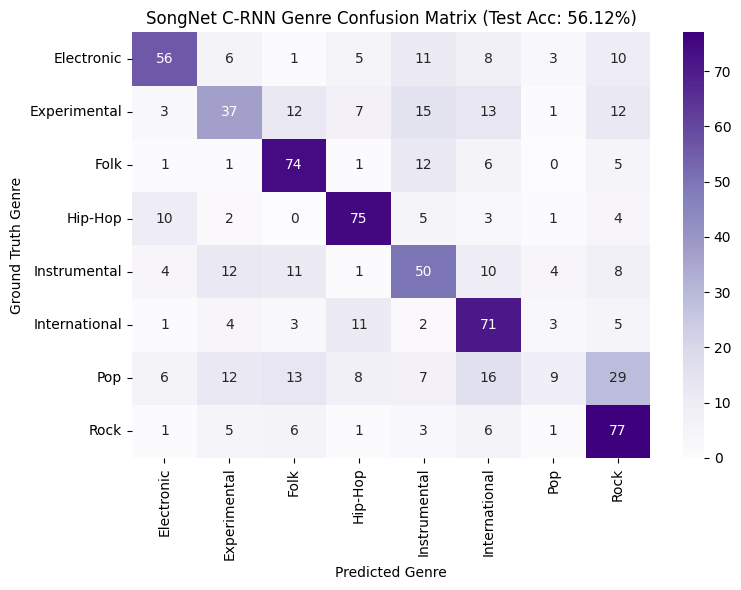

Classification Report:
               precision    recall  f1-score   support

   Electronic       0.68      0.56      0.62       100
 Experimental       0.47      0.37      0.41       100
         Folk       0.62      0.74      0.67       100
      Hip-Hop       0.69      0.75      0.72       100
 Instrumental       0.48      0.50      0.49       100
International       0.53      0.71      0.61       100
          Pop       0.41      0.09      0.15       100
         Rock       0.51      0.77      0.62       100

     accuracy                           0.56       800
    macro avg       0.55      0.56      0.54       800
 weighted avg       0.55      0.56      0.54       800



In [9]:
# ==========================================
# CELL 8: Test Set Evaluation & Paper Comparison
# ==========================================
songnet_model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        probs, _ = songnet_model(inputs)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

test_acc = accuracy_score(all_targets, all_preds) * 100
macro_f1 = f1_score(all_targets, all_preds, average='macro')

print('==========================================')
print('   FINAL MODEL ACCURACY COMPARISON        ')
print('==========================================')
print(f'  • SongNet C-RNN (Test Acc): {test_acc:.2f}% | Macro F1: {macro_f1:.4f}')
for name, res in baseline_results.items():
    print(f'  • {name:<22}: {res["test_acc"]:.2f}% | Macro F1: {res["macro_f1"]:.4f}')

# Plot Heatmap
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=GENRES, yticklabels=GENRES)
plt.title(f'SongNet C-RNN Genre Confusion Matrix (Test Acc: {test_acc:.2f}%)')
plt.xlabel('Predicted Genre')
plt.ylabel('Ground Truth Genre')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print('Classification Report:')
print(classification_report(all_targets, all_preds, target_names=GENRES))
